# НИРС по курсу "Оперативный анализ данных" на тему "Анализ датасета"

**Выполнил:**  
Студент группы ИУ5-52Б, Волов А. П.  
**Проверил:**  
Преподаватель кафедры ИУ5, Маслеников К. Ю.  

## Описания данных для анализа  

Набор данных «IMDb Movies» представляет собой структурированную коллекцию записей о полнометражных фильмах, агрегированных с помощью сайта IMDb.
Каждая запись в датасете соответствует отдельному фильму и характеризуется набором 15 параметров (полей).  

1.	Title — название фильма.  
2.	Summary — описание фильма, включающее краткое содержание сюжета или завязки.  
3.	Director — режиссер фильма.  
4.	Writer — сценарист фильма.  
5.	Main Genres — небольшой список жанров, к которым можно отнести фильм.  
6.	Motion Picture Rating — возрастной рейтинг фильма.  
7.	Release Year — год выхода фильма в прокат.  
8.	Runtime (Minutes) — продолжительность фильма в минутах.  
9.	Rating (Out of 10) — рейтинг фильма по 10-и бальной шкале, сформированный на основе среднего значения оценок зрителей с сайта IMBd.  
10.	Number of Ratings (in thousands) — количество зрителей в тысячах, оценивших фильм на сайте IMBd.  
11.	Budget (in millions) — денежная сумма в миллионах долларов, потраченная на производство фильма.  
12.	Gross in US & Canada (in millions) — денежная сумма в миллионах долларов, собранная фильмом в прокате в США и Канаде.  
13.	Gross worldwide (in millions) — денежная сумма в миллионах долларов, собранная фильмом в прокате во всех странах, где проходил прокат (кроме США и Канады).  
14.	Opening Weekend in US — денежная сумма в миллионах долларов, собранная фильмом в прокате в США и Канаде в первые выходные.  
15.	Gross Opening Weekend (in millions) — денежная сумма в миллионах долларов, собранная фильмом в прокате во всех странах, где проходил прокат (кроме США и Канады), в первые выходные.  

## Формулирование гипотез  

Для выбранного датасета были сформулированы 5 гипотез, подтверждение и опровержение которых будет осуществляться в ходе анализа.  

1.	Гипотеза №1. Существует статистически значимая корреляция между годом выпуска фильма и его зрительским рейтингом. Предполагается, что более старые фильмы в среднем имеют более высокие зрительские оценки.
2.	Гипотеза №2. Существует статистически значимая корреляция между бюджетом фильма и его итоговой прибылью. Предполагается, что чем выше бюджет фильма, тем выше итоговая прибыль.  
3.	Гипотеза №3. Существует статически значимая корреляция между кассовыми сборами фильма и его зрительскими оценками. Предполагается, что чем выше зрительский рейтинг фильма, там выше его кассовые сборы.  
4.	Гипотеза №4. Существует статически значимая корреляция между кассовыми сборами фильма и его жанром. Предполагается, что определенные жанры потенциально могут привести к более высоким кассовым сборам, чем другие.  
5.	Гипотеза №5. Существует статистически значимая корреляция между возрастным рейтингом фильма и количеством его зрительских оценок на сайте IMBd. Предполагается, что фильмы взрослой возрастной аудитории имеют в среднем больше зрительских оценок на сайте IMBd, чем фильмы более детской возрастной аудитории.  


## Подготовка данных для анализа  

В ходе подготовки данных был выполнен ряд преобразований для обеспечения качества и релевантности последующего анализа. Исходный датасет был загружен с использованием библиотеки pandas. Из данных были последовательно удалены: 

 - строки с отсутствующими значениями бюджета фильмов;  
 - строки, содержащие пропуски в любых колонках;  
 - дублирующиеся записи.

Для расширения аналитических возможностей была добавлена новая расчетная колонка "Profit (in millions)", отражающая итоговую прибыль, вычисленную как сумма сборов в США, Канаде и остальном мире за вычетом производственного бюджета.
Итоговое количество уникальных записей в датасете составило 9080.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('data.csv')

needed_columns = [
    'Title',                         
    'Main Genres',                  
    'Motion Picture Rating',         
    'Release Year',               
    'Runtime (Minutes)',          
    'Rating (Out of 10)',         
    'Number of Ratings (in thousands)', 
    'Budget (in millions)',         
    'Gross in US & Canada (in millions)',  
    'Gross worldwide (in millions)'
]

df = df[needed_columns].copy()
df = df.dropna()  

rating_mapping = {
    'G': '0+',
    'TV-PG': '0+',
    'GP': '0+',
    'PG': '6+',
    'PG-13': '12+',
    'TV-14': '12+',
    '13+': '12+',
    'R': '16+',
    'M': '16+',
    'M/PG': '16+',
    '16+': '16+',
    'Not Rated': '18+',
    'Passed': '18+',
    'Unrated': '18+',
    'Approved': '18+',
    'NC-17': '18+',
    'TV-MA': '18+',
    'X': '18+',
    '18+': '18+'
}

def convert_rating(rating):
    rating = str(rating).strip()

    if rating in rating_mapping:
        return rating_mapping[rating]
    else:
        return '18+'

# Применяем преобразование
df['Motion Picture Rating'] = df['Motion Picture Rating'].apply(convert_rating)
df = df[df['Budget (in millions)'] <= 400].copy()

df['Profit (in millions)'] = (df['Gross in US & Canada (in millions)'] + 
                              df['Gross worldwide (in millions)']) - df['Budget (in millions)']

display(df)

,Title,Main Genres,Motion Picture Rating,Release Year,Runtime (Minutes),Rating (Out of 10),Number of Ratings (in thousands),Budget (in millions),Gross in US & Canada (in millions),Gross worldwide (in millions),Profit (in millions)
1,The Hunger Games: The Ballad of Songbirds & Sn...,"Action,Adventure,Drama",12+,2023.0,157.0,7.2,37.0,100.0,105.043,191.729,196.772
5,Oppenheimer,"Biography,Drama,History",16+,2023.0,3.0,8.5,525.0,100.0,325.367,950.554,1175.921
7,The Marvels,"Action,Adventure,Fantasy",12+,2023.0,105.0,6.0,57.0,220.0,77.927,188.197,46.124
8,Wish,"Animation,Adventure,Comedy",6+,2023.0,95.0,5.9,6.4,200.0,33.974,51.276,-114.750
9,The Creator,"Action,Adventure,Drama",12+,2023.0,133.0,6.9,79.0,80.0,40.775,104.181,64.956
...,...,...,...,...,...,...,...,...,...,...,...
9063,Carandiru,"Crime,Drama",16+,2003.0,145.0,7.6,21.0,12.0,0.216,10.782,-1.002
9066,Don Juan DeMarco,"Comedy,Drama,Romance",12+,1994.0,97.0,6.7,53.0,25.0,22.150,68.793,65.943
9076,The Marine,"Action,Comedy,Drama",12+,2006.0,92.0,4.7,35.0,20.0,18.845,22.166,21.011
9079,Young Adam,"Crime,Drama",18+,2003.0,98.0,6.4,15.0,6.4,0.767,2.562,-3.071


## Анализ данных

### Гипотеза №1  

Согласно гипотезе №1, существует статистически значимая корреляция между годом и количеством фильмов, выходящих в прокат в этот год. Предполагается, что с каждым годом все больше фильмов, выходящих в прокат.

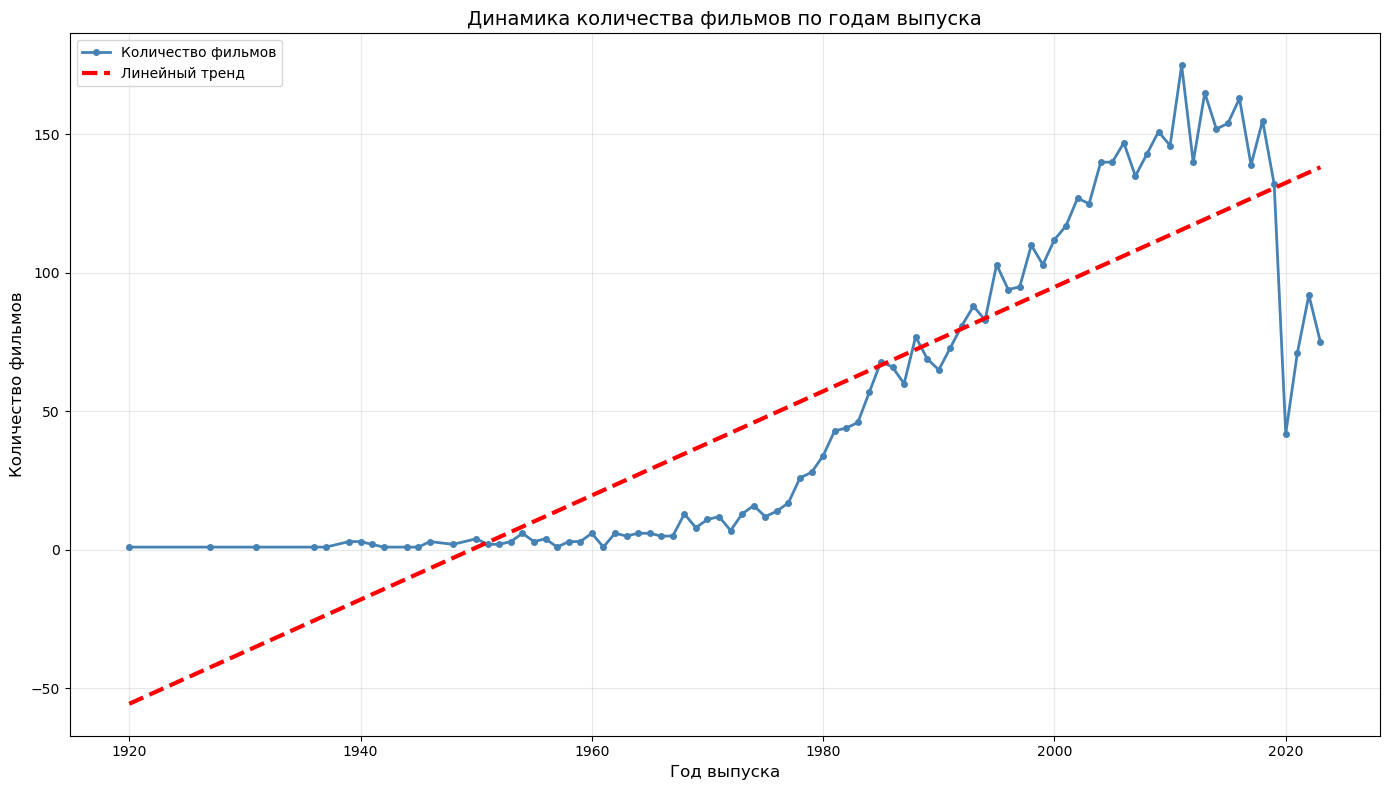

In [3]:
movies_by_year = df['Release Year'].value_counts().sort_index().reset_index()
movies_by_year.columns = ['Year', 'Number of Movies']

# Линейный график с трендом
plt.figure(figsize=(14, 8))

# Основной график количества фильмов
plt.plot(movies_by_year['Year'], 
         movies_by_year['Number of Movies'], 
         marker='o', 
         linewidth=2, 
         markersize=4,
         color='steelblue',
         label='Количество фильмов')

# Линейная регрессия (тренд)
z = np.polyfit(movies_by_year['Year'], movies_by_year['Number of Movies'], 1)
p = np.poly1d(z)
plt.plot(movies_by_year['Year'], 
         p(movies_by_year['Year']), 
         color='red', 
         linewidth=3,
         linestyle='--',
         label=f'Линейный тренд')

plt.title('Динамика количества фильмов по годам выпуска', fontsize=14)
plt.xlabel('Год выпуска', fontsize=12)
plt.ylabel('Количество фильмов', fontsize=12)

# Добавляем сетку и легенду
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Гипотеза №2  

Согласно гипотезе №2, существует статистически значимая корреляция между бюджетом фильма и его итоговой прибылью. Чем выше бюджет фильма, тем выше итоговая прибыль.

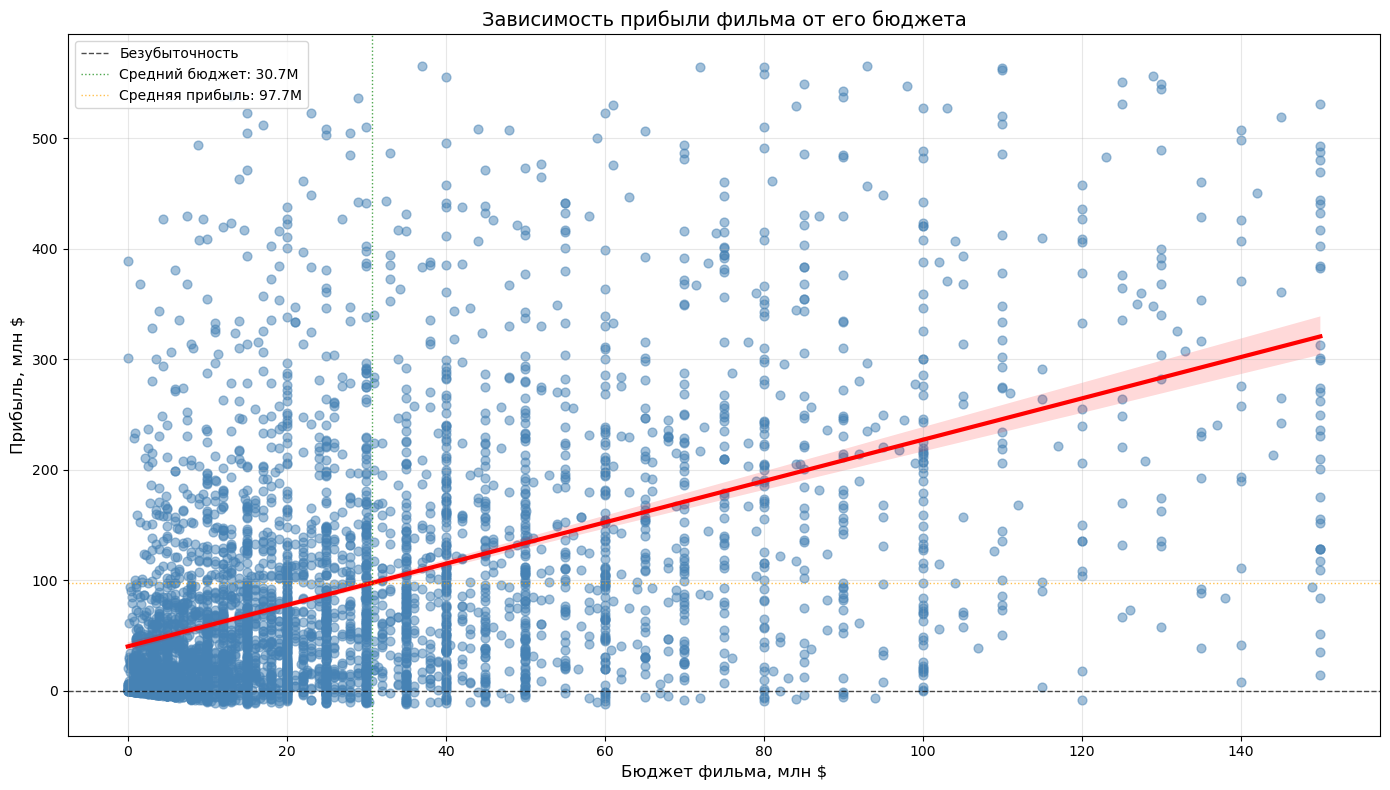

In [4]:
df_filtered = df[
    (df['Budget (in millions)'].notna()) & 
    (df['Budget (in millions)'] > 0) &
    (df['Profit (in millions)'].notna())
].copy()

# Ограничиваем выбросы для лучшей визуализации
budget_limit = df_filtered['Budget (in millions)'].quantile(0.95)
profit_limit = df_filtered['Profit (in millions)'].quantile(0.95)

df_plot = df_filtered[
    (df_filtered['Budget (in millions)'] <= budget_limit) &
    (df_filtered['Profit (in millions)'] <= profit_limit) &
    (df_filtered['Profit (in millions)'] >= df_filtered['Profit (in millions)'].quantile(0.05))
]

# Scatter plot с регрессией
plt.figure(figsize=(14, 8))

sns.regplot(data=df_plot,
            x='Budget (in millions)',
            y='Profit (in millions)',
            scatter_kws={'alpha': 0.5, 's': 40, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 3},
            ci=95)

plt.title('Зависимость прибыли фильма от его бюджета', fontsize=14)
plt.xlabel('Бюджет фильма, млн $', fontsize=12)
plt.ylabel('Прибыль, млн $', fontsize=12)

# Добавляем линии для нулевой прибыли и средних значений
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Безубыточность')
plt.axvline(x=df_plot['Budget (in millions)'].mean(), color='green', linestyle=':', linewidth=1, alpha=0.7, label=f'Средний бюджет: {df_plot["Budget (in millions)"].mean():.1f}M')
plt.axhline(y=df_plot['Profit (in millions)'].mean(), color='orange', linestyle=':', linewidth=1, alpha=0.7, label=f'Средняя прибыль: {df_plot["Profit (in millions)"].mean():.1f}M')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Гипотеза №3  
Согласно гипотезе, существует статически значимая корреляция между продолжительностью фильма и его зрительскими оценками. Фильмы средней продолжительности (90–120 минут) более предпочтительные для зрителя, нежели более короткие или длинные фильмы.

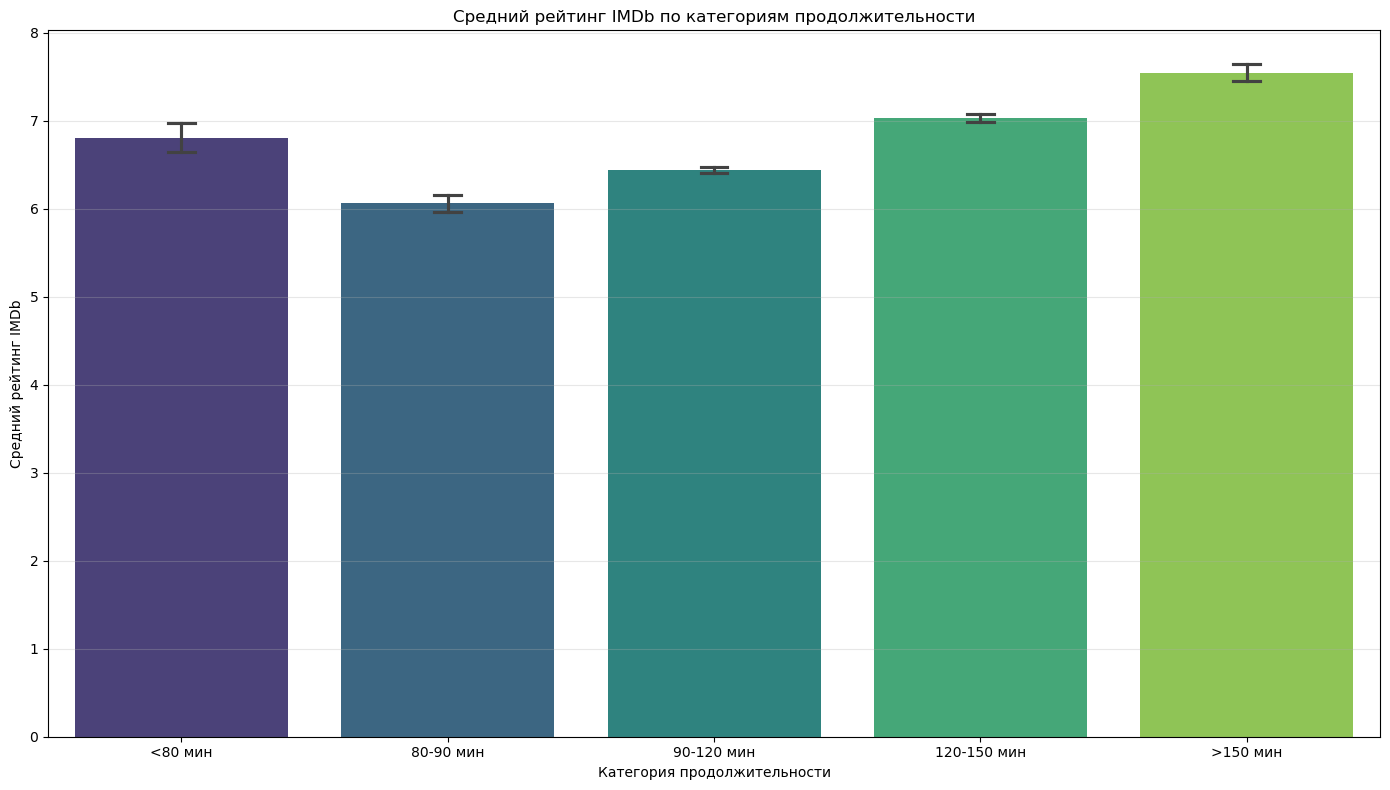

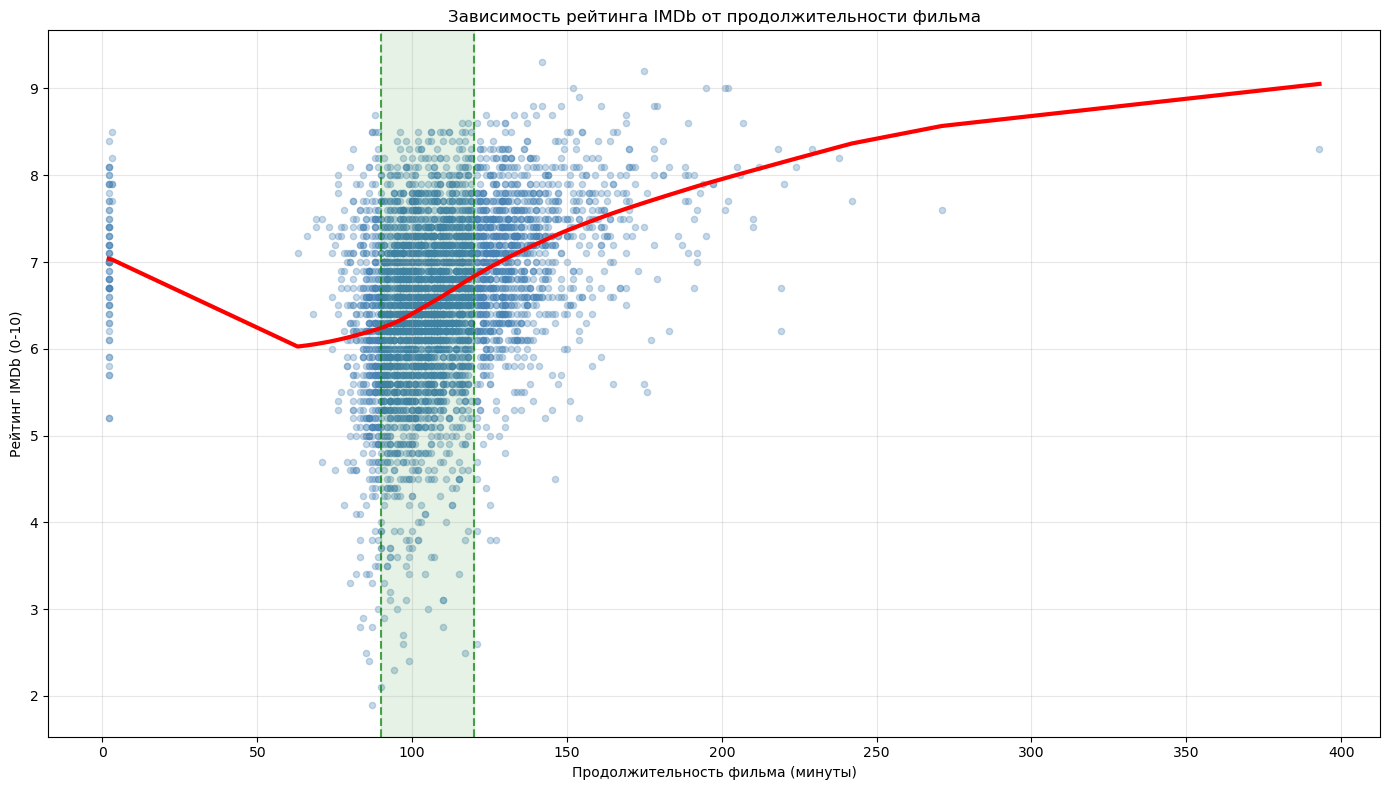

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df['Runtime Category'] = pd.cut(df['Runtime (Minutes)'], 
                                 bins=[0, 80, 90, 120, 150, 300],
                                 labels=['<80 мин', '80-90 мин', '90-120 мин', '120-150 мин', '>150 мин'])

plt.figure(figsize=(14, 8))
sns.barplot(data=df, 
            x='Runtime Category', 
            y='Rating (Out of 10)',
            hue='Runtime Category',
            order=['<80 мин', '80-90 мин', '90-120 мин', '120-150 мин', '>150 мин'],
            errorbar=('ci', 95),
            palette='viridis',
            capsize=0.1,
            legend=False)
plt.title('Средний рейтинг IMDb по категориям продолжительности')
plt.xlabel('Категория продолжительности')
plt.ylabel('Средний рейтинг IMDb')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))
sns.regplot(data=df, 
            x='Runtime (Minutes)', 
            y='Rating (Out of 10)',
            scatter_kws={'alpha': 0.3, 's': 20, 'color': 'steelblue'},
            lowess=True,
            line_kws={'color': 'red', 'linewidth': 3})
plt.axvline(x=90, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axvline(x=120, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axvspan(90, 120, alpha=0.1, color='green')
plt.title('Зависимость рейтинга IMDb от продолжительности фильма')
plt.xlabel('Продолжительность фильма (минуты)')
plt.ylabel('Рейтинг IMDb (0-10)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Гипотеза №4

Согласно гипотезе №4, существует статически значимая корреляция между кассовыми сборами фильма и его жанром. Предполагается, что определенные жанры потенциально могут привести к более высоким кассовым сборам, чем другие.

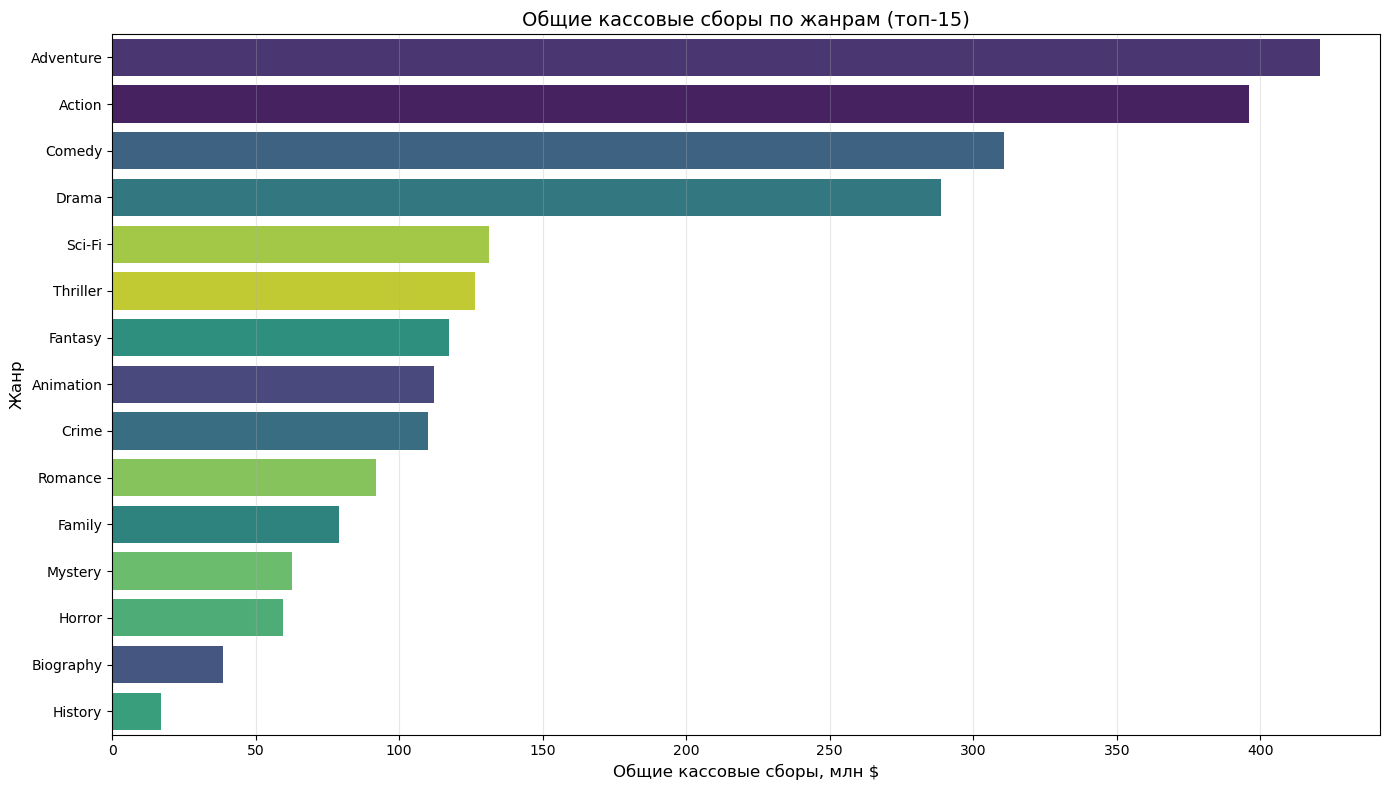

In [6]:
# Разделяем жанры
df['Genres_Split'] = df['Main Genres'].str.split(',')
genre_exploded = df.explode('Genres_Split')
genre_exploded['Genre'] = genre_exploded['Genres_Split'].str.strip()

# Общие сборы
genre_exploded['Total Gross (in millions)'] = (
    genre_exploded['Gross in US & Canada (in millions)'].fillna(0) + 
    genre_exploded['Gross worldwide (in millions)'].fillna(0)
) / 1000

# Фильтруем только с сборами > 0
genre_gross = genre_exploded[genre_exploded['Total Gross (in millions)'] > 0].copy()

# 2. ГРАФИК: ОБЩИЕ СБОРЫ ПО ЖАНРАМ (ТОП-15)
plt.figure(figsize=(14, 8))
top_total_genres = genre_gross.groupby('Genre')['Total Gross (in millions)'].sum().nlargest(15)
top_total_df = genre_gross[genre_gross['Genre'].isin(top_total_genres.index)]
total_genre_order = top_total_genres.index.tolist()

sns.barplot(data=top_total_df.groupby('Genre')['Total Gross (in millions)'].sum().reset_index(),
            x='Total Gross (in millions)',
            y='Genre',
            hue='Genre',
            order=total_genre_order,
            palette='viridis',
            legend=False)

plt.title('Общие кассовые сборы по жанрам (топ-15)', fontsize=14)
plt.xlabel('Общие кассовые сборы, млн $', fontsize=12)
plt.ylabel('Жанр', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Гипотеза №5  

Согласно гипотезе №5, существует статистически значимая корреляция между бюджетом фильма и его итоговой прибылью. Чем выше бюджет фильма, тем выше итоговая прибыль.

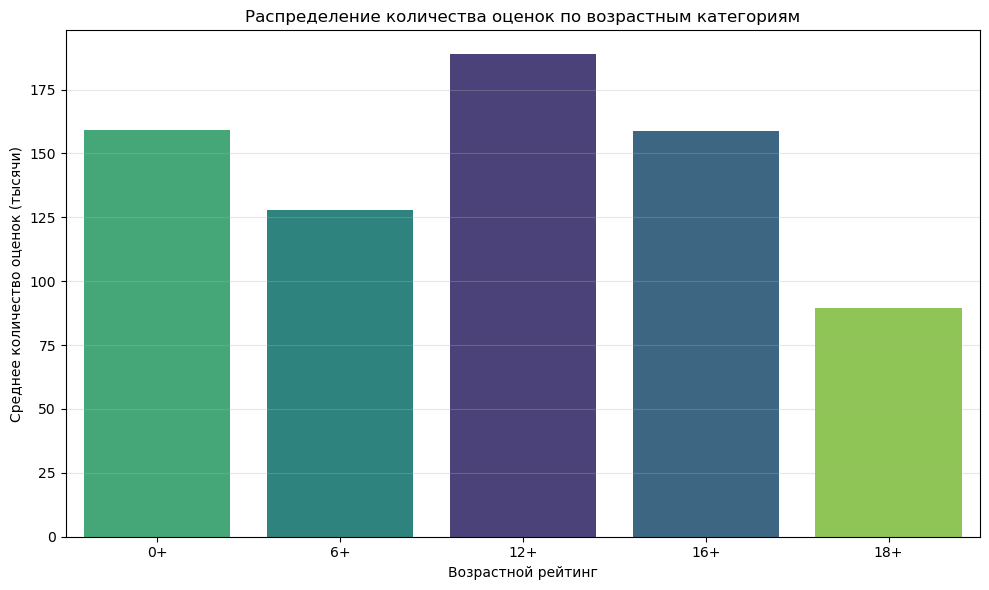

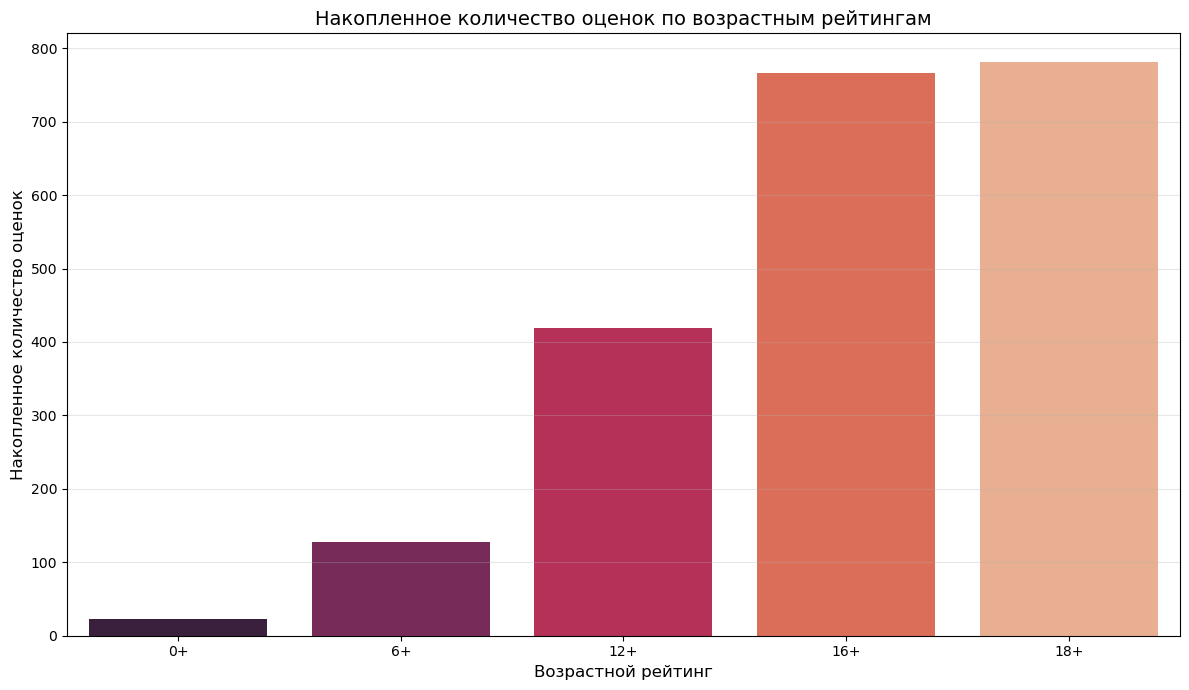

In [35]:
age_order = ['0+', '6+', '12+', '16+', '18+']
df_filtered = df[df['Motion Picture Rating'].isin(age_order)].copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=df_filtered, 
            x='Motion Picture Rating', 
            y='Number of Ratings (in thousands)',
            hue='Motion Picture Rating',
            order=age_order,
            palette='viridis',
            legend=False,
            errorbar=None)
plt.title('Распределение количества оценок по возрастным категориям')
plt.xlabel('Возрастной рейтинг')
plt.ylabel('Среднее количество оценок (тысячи)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

cumulative_data = []

# Для каждого рейтинга в порядке возрастания
for i, rating in enumerate(age_order):
    # Берем все фильмы с текущим и всеми предыдущими рейтингами
    ratings_to_include = age_order[:i+1]
    df_subset = df_filtered[df_filtered['Motion Picture Rating'].isin(ratings_to_include)]
    
    # Считаем кумулятивную сумму оценок
    cumulative_sum = df_subset['Number of Ratings (in thousands)'].sum() / 1000
    cumulative_data.append({'Motion Picture Rating': rating, 
                           'Cumulative Ratings (thousands)': cumulative_sum})

df_cumulative = pd.DataFrame(cumulative_data)

plt.figure(figsize=(12, 7))

sns.barplot(data=df_cumulative,
            x='Motion Picture Rating',
            y='Cumulative Ratings (thousands)',
            hue='Motion Picture Rating',
            order=age_order,
            palette='rocket',
            legend=False)

plt.title('Накопленное количество оценок по возрастным рейтингам', fontsize=14)
plt.xlabel('Возрастной рейтинг', fontsize=12)
plt.ylabel('Накопленное количество оценок', fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

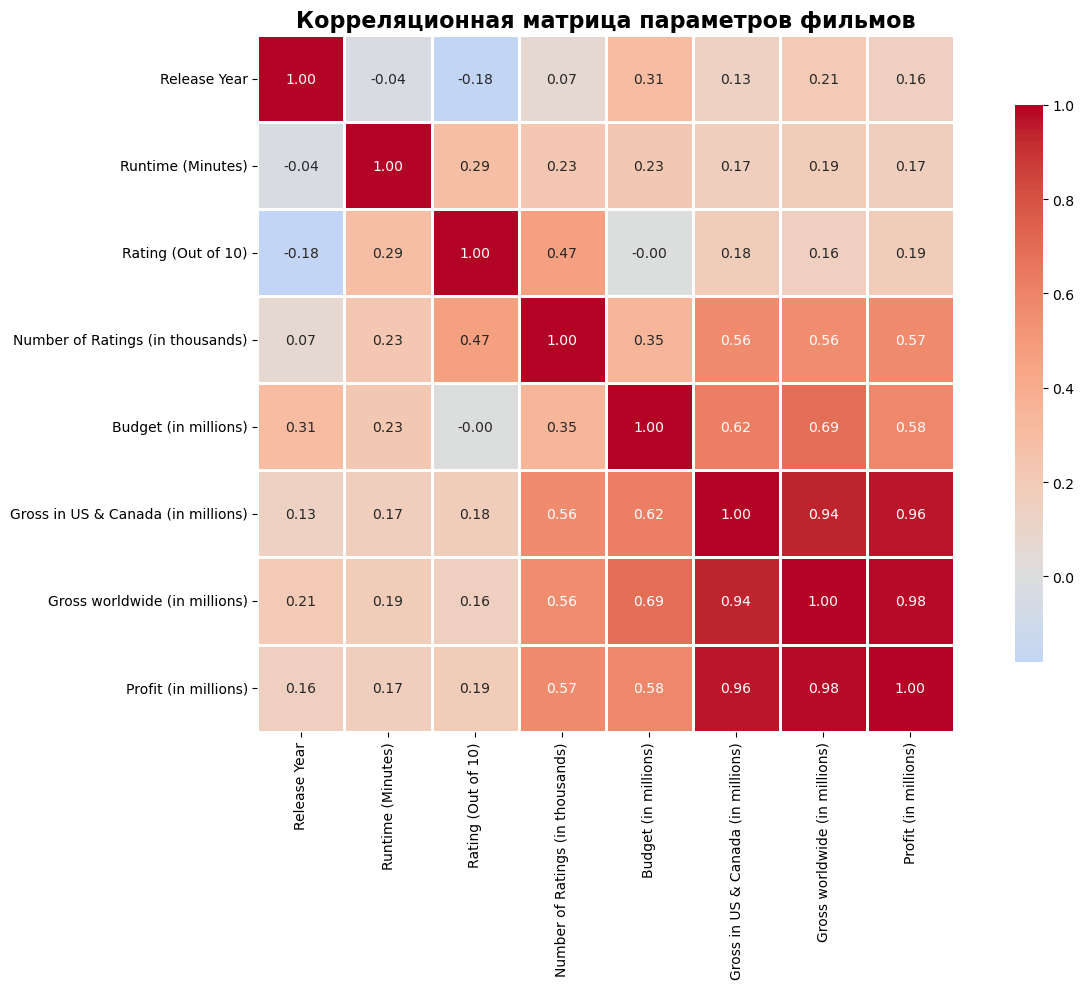

In [7]:
# Выбираем только числовые колонки для корреляционной матрицы
numeric_columns = [
    'Release Year',
    'Runtime (Minutes)',
    'Rating (Out of 10)',
    'Number of Ratings (in thousands)',
    'Budget (in millions)',
    'Gross in US & Canada (in millions)',
    'Gross worldwide (in millions)',
    'Profit (in millions)'
]

# Создаем датафрейм только с числовыми колонками
df_numeric = df[numeric_columns].copy()

# Рассчитываем корреляционную матрицу
correlation_matrix = df_numeric.corr()

# Создаем маску для верхнего треугольника
mask = np.triu(np.ones_like(correlation_matrix))

# Упрощенная версия (только тепловая карта без кластеризации)
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица параметров фильмов', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()